# **Basic Classififcation Model**

#### Import Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm
import math
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator


#### Dataset

In [3]:
dataset = [
    (1,"Introduction to NLP"),
    (2,"Basics of PyTorch"),
    (1,"NLP Techniques for Text Classification"),
    (3,"Named Entity Recognition with PyTorch"),
    (3,"Sentiment Analysis using PyTorch"),
    (3,"Machine Translation with PyTorch"),
    (1," NLP Named Entity,Sentiment Analysis,Machine Translation "),
    (1," Machine Translation with NLP "),
    (1," Named Entity vs Sentiment Analysis  NLP "),
    (3,"he painted the car red"),
    (1,"he painted the red car")
    ]

Initiate Tokenizor

In [6]:
tokenizor = get_tokenizer("basic_english")

def yield_token (dataset):
    for id, text in dataset:
        yield tokenizor(text)

#### Build Vocabulary

In [7]:
vocab =  build_vocab_from_iterator(yield_token(dataset), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

In [8]:
vocab["he"]

12

#### Text Pipeline Implementing

This is use for enode the input data

In [20]:
def text_pipeline(input):
    return vocab(tokenizor(input))

In [ ]:
def label_pipeline(input):
    return int(input) - 1

## **Section of Zero Padding**


In many PyTorch applications, maintaining consistent batch sizes is essential. Since input sequences often have varying lengths, **zero padding** is used to make them uniform within a batch.

You can achieve this using the `pad_sequence` function. Consider a list of tensors where each tensor represents a sequence with a different length.

The `pad_sequence` function from `torch.nn.utils.rnn` is designed to handle this scenario by padding all sequences to the same length along a specified dimension. This is especially useful in tasks like Natural Language Processing (NLP), where sentences (after tokenization) naturally vary in length.

### How it works:

1. **Input**  
   `pad_sequence` accepts a list of tensors, where each tensor represents a sequence. These sequences can have different lengths.

2. **Padding**  
   The function pads shorter sequences with zeros (or a specified padding value) so that all sequences match the length of the longest sequence in the list.

3. **Output**  
   The result is a single tensor where all sequences are stacked along a specified dimension (default is the first dimension), forming a batch with uniform sequence length.

In [27]:
sequence = [torch.tensor([j for j in range(1, i)]) for i in range(2,10)]
sequence

[tensor([1]),
 tensor([1, 2]),
 tensor([1, 2, 3]),
 tensor([1, 2, 3, 4]),
 tensor([1, 2, 3, 4, 5]),
 tensor([1, 2, 3, 4, 5, 6]),
 tensor([1, 2, 3, 4, 5, 6, 7]),
 tensor([1, 2, 3, 4, 5, 6, 7, 8])]

In [22]:
from torch.nn.utils.rnn import pad_sequence

In [ ]:
# we use pad_sequence to get all the tensors to a fixed length
# this will stack the tensors after it convert to same length
padded_sequence = pad_sequence(sequence,batch_first=True, padding_value=0)
padded_sequence

tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 2, 0, 0, 0, 0, 0, 0],
        [1, 2, 3, 0, 0, 0, 0, 0],
        [1, 2, 3, 4, 0, 0, 0, 0],
        [1, 2, 3, 4, 5, 0, 0, 0],
        [1, 2, 3, 4, 5, 6, 0, 0],
        [1, 2, 3, 4, 5, 6, 7, 0],
        [1, 2, 3, 4, 5, 6, 7, 8]])

## **Positional Encoding**

In [28]:
input_seq = "he painted the car red he painted the red car"

tokens = text_pipeline(input_seq)
tokens

[12, 13, 15, 11, 14, 12, 13, 15, 14, 11]

In [31]:
tokens_tensor = torch.tensor(tokens)
tokens_tensor

tensor([12, 13, 15, 11, 14, 12, 13, 15, 14, 11])

In [32]:
num_dims = 3
vocab_size = len(vocab)

embedding_layer = nn.Embedding(vocab_size,num_dims)

In [34]:
embedd_out = embedding_layer(tokens_tensor)
embedd_out, embedd_out.shape

(tensor([[-2.1652, -0.6954,  0.1091],
         [-0.2342, -0.1414,  0.0476],
         [-1.8939,  0.4122, -0.9346],
         [ 0.3046,  0.0735,  0.2412],
         [ 0.5822,  0.2288,  0.0270],
         [-2.1652, -0.6954,  0.1091],
         [-0.2342, -0.1414,  0.0476],
         [-1.8939,  0.4122, -0.9346],
         [ 0.5822,  0.2288,  0.0270],
         [ 0.3046,  0.0735,  0.2412]], grad_fn=<EmbeddingBackward0>),
 torch.Size([10, 3]))

In [36]:
# for plotting purpose we need to convert this to a numpy array
embedd_out_array = embedd_out.detach().numpy()
embedd_out_array, embedd_out_array.shape

(array([[-2.1651855 , -0.69544965,  0.10910032],
        [-0.23424378, -0.14137329,  0.04762709],
        [-1.8938894 ,  0.4121855 , -0.9346479 ],
        [ 0.30464184,  0.07347731,  0.24119765],
        [ 0.5821719 ,  0.22884957,  0.02699593],
        [-2.1651855 , -0.69544965,  0.10910032],
        [-0.23424378, -0.14137329,  0.04762709],
        [-1.8938894 ,  0.4121855 , -0.9346479 ],
        [ 0.5821719 ,  0.22884957,  0.02699593],
        [ 0.30464184,  0.07347731,  0.24119765]], dtype=float32),
 (10, 3))

#### **Plot Embedding**

In [40]:
def plot_embedding (embedding_array, name,vocab):
    
    fig = plt.figure()
    ax = fig.add_subplot(111,projection='3d')
    
    #plot the data points
    ax.plot(embedding_array[:,0], embedding_array[:,1],embedding_array[:,2])
    
    # labels for data point
    for j, label in enumerate(name):
        id = vocab.get_stoi()[label]
        ax.text(embedding_array[j,0],embedding_array[j,1],embedding_array[j,2],label)
    
    ax.set_xlabel("X Label")
    ax.set_ylabel("Y Label")
    ax.set_zlabel("Z Label")
    
    plt.show()

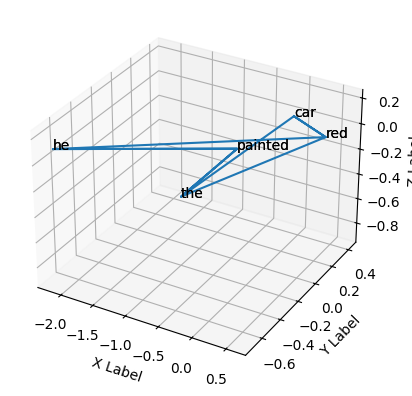

In [41]:
plot_embedding(embedd_out_array,tokenizor(input_seq), vocab)